In [24]:
# Домашка 2

# Дан пайплайн для тренировки сегментации с датасетом Oxford-IIIT Pet. 
# Задача - доделать тренировку и провести эксперименты 

# Критерии
# 3 - просто доделан класс U-Net и обучен. Можно сделать его чисто на своих свертках 
# / либо взять готовый бекбон из torchvision.models по типу ResNet34 и достать из него признаки 
# для skip connections

# 4 - обучен U-Net и проведен перебор простых гиперпараметров в конфиге (lr, batch size и тд) 
# с графиками после тренировки. Перебор хватит делать по 3 значениям для 2 параметров. 
# После полезно написать мысли, почему получились такие результаты

# 5 - обучен U-Net , проведен перебор гиперпаметров выше и проверена какая-либо идея по 
# модификации U-Net (сделать глубже, добавить нормализацию слоев, поменять бекбон на другой, и тд). 
# Также сделать 1-2 графика с результатами. После написать мысли, почему получились такие результаты

# Дедлайн - 2 недели (то есть 21.03)

# В пайплайне есть конфиг, с ним можно удобно менять параметры, если нужно туда можно добавить 
# еще что-то, чтобы не перезапускать код много раз. Перебор гиперпараметров можно сделать в цикле 
# над всем обучением или в тулзах типо WandB если уже юзали их. Если что-то хочется переделать в пайплайне 
# под свое удобство - полная свобода здесь

In [25]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch.nn.functional as F_torch 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [26]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 5
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [27]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),   # добавили BN — полезно с attention
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [28]:

class AttentionGate(nn.Module):
    """
    Attention Gate из "Attention U-Net" (Oktay et al., 2018).

    x : skip connection  (B, F_x, H, W)   ← из энкодера
    g : gating signal    (B, F_g, H/2, W/2) ← из декодера (после up)

    Возвращает x̂ = α ⊙ x, где α ∈ [0,1]
    """
    def __init__(self, F_x, F_g, F_int):
        super().__init__()
        # Проекция skip connection → F_int каналов
        self.W_x = nn.Sequential(
            nn.Conv2d(F_x, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        # Проекция gating signal → F_int каналов
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        # Финальная свёртка → 1 канал (маска)
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        # g может быть меньше x по spatial — upsampling g до размера x
        g_up = F_torch.interpolate(g, size=x.shape[2:], mode='bilinear', align_corners=True)

        q_x = self.W_x(x)        
        q_g = self.W_g(g_up)    

        z = self.relu(q_x + q_g)    
        alpha = self.psi(z)         

        return x * alpha            # фильтруем skip connection

In [29]:
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # ── Bottleneck ────────────────────────────────────────
        self.bottleneck = DoubleConv(512, 1024)

        # ── Attention Gates (F_x, F_g, F_int) ────────────────
        # F_int = F_x // 2  — стандартная эвристика
        # self.ag4 = AttentionGate(F_x=512,  F_g=1024, F_int=256)
        # self.ag3 = AttentionGate(F_x=256,  F_g=512,  F_int=128)
        # self.ag2 = AttentionGate(F_x=128,  F_g=256,  F_int=64)
        # self.ag1 = AttentionGate(F_x=64,   F_g=128,  F_int=32)

        # ── Decoder ───────────────────────────────────────────
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)   # 512 (up) + 512 (filtered skip)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # ── Output ────────────────────────────────────────────
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))
    
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
    
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
    
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
    
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
    
        return self.final(d1)
    # def forward(self, x):
    #     # Encoder
    #     e1 = self.enc1(x)                    
    #     e2 = self.enc2(self.pool1(e1))      
    #     e3 = self.enc3(self.pool2(e2))       
    #     e4 = self.enc4(self.pool3(e3))      

    #     # Bottleneck
    #     b = self.bottleneck(self.pool4(e4))  

    #     # Decoder + Attention Gates
    #     d4 = self.up4(b)                               
    #     # e4 = self.ag4(x=e4, g=b)                       
    #     d4 = self.dec4(torch.cat([d4, e4], dim=1))     

    #     d3 = self.up3(d4)                            
    #     e3 = self.ag3(x=e3, g=d4)
    #     d3 = self.dec3(torch.cat([d3, e3], dim=1))

    #     d2 = self.up2(d3)                            
    #     e2 = self.ag2(x=e2, g=d3)
    #     d2 = self.dec2(torch.cat([d2, e2], dim=1))

    #     d1 = self.up1(d2)                               
    #     e1 = self.ag1(x=e1, g=d2)
    #     d1 = self.dec1(torch.cat([d1, e1], dim=1))

    #     return self.final(d1)

In [30]:
# class UNet(nn.Module):
#     def __init__(self, in_channels=3, out_channels=1):
#         super(UNet, self).__init__()

#         # тут слои обозначить для encoder, bottleneck и decoder

#     def forward(self, x):
#         # тут предсказать маску

#         return

In [31]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        #mask = F.pil_to_tensor(mask).float()
        mask = torchvision.transforms.functional.pil_to_tensor(mask).float()
        return image, mask

In [32]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = AttentionUNet().to(config.device)
        #self.criterion = None # какой лосс удобный возьмем для бинарной сегментации?
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)
        self.history = {'val_loss': [], 'val_iou': [], 'val_f1': []}
        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()

In [33]:
# БЛОК 1: Инициализация + полный цикл обучения
trainer = Trainer(config)
trainer.run()  # train + val + test

100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 1 / 5, Train Loss: 0.4768, Val Loss: 0.3979, Val IoU: 0.7965, Val F1-score: 0.8811


100%|██████████| 23/23 [00:11<00:00,  1.95it/s]


Epoch 2 / 5, Train Loss: 0.3537, Val Loss: 0.3360, Val IoU: 0.8281, Val F1-score: 0.9004


100%|██████████| 23/23 [00:11<00:00,  1.97it/s]


...

Epoch 4 / 5, Train Loss: 0.2734, Val Loss: 0.2809, Val IoU: 0.8519, Val F1-score: 0.9155


100%|██████████| 23/23 [00:11<00:00,  1.98it/s]


Epoch 5 / 5, Train Loss: 0.2439, Val Loss: 0.2696, Val IoU: 0.8573, Val F1-score: 0.9185
Testing...


100%|██████████| 115/115 [01:00<00:00,  1.92it/s]

Test Loss: 0.2602, Test IoU: 0.8613, Test F1-score: 0.9203


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].


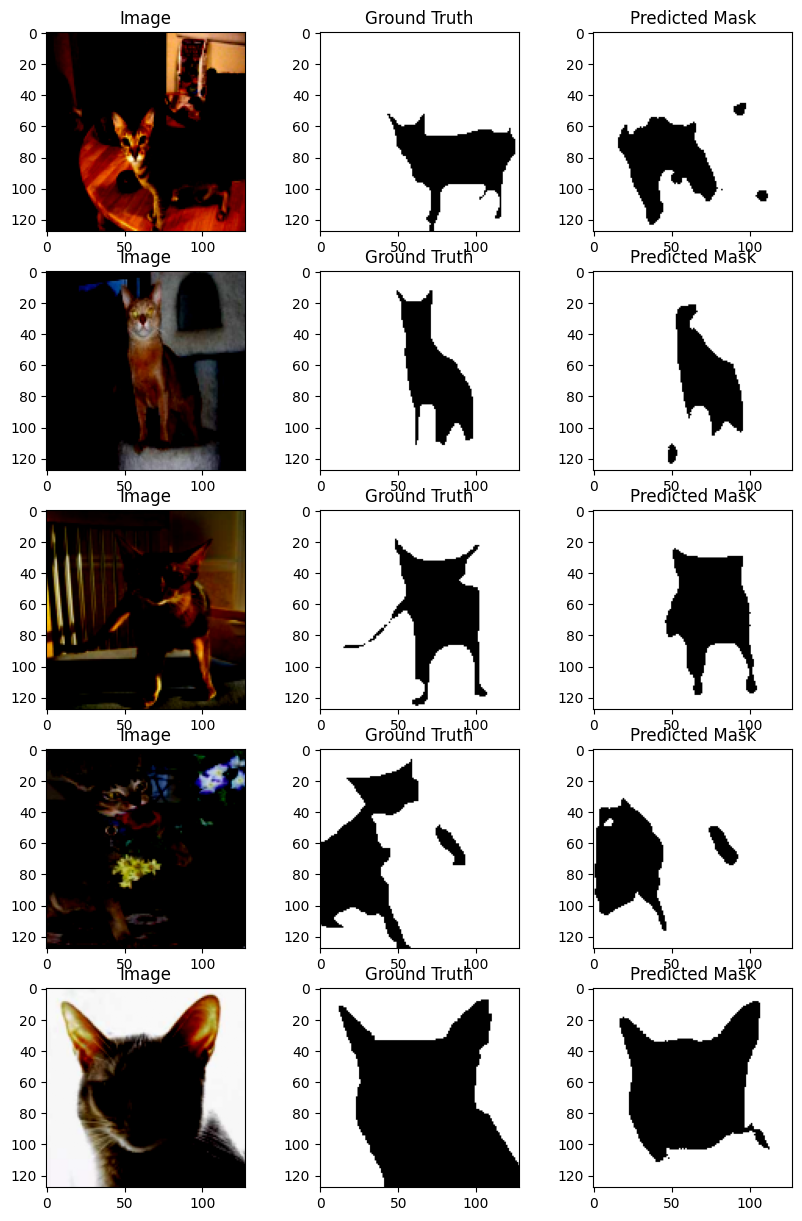

In [34]:
# # БЛОК 2: Визуализация кривых обучения
# trainer.plot_training_history()   

# БЛОК 3: Инференс на примерах
trainer.inference_and_plot_samples(n_samples=5)


ПЕРЕБОР ГИПЕРПАРАМЕТРОВ

[1/9] Learning Rate: 0.0001, Batch Size: 8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:12<00:00,  7.19it/s]


Epoch 1 / 15, Train Loss: 0.4027, Val Loss: 0.3403, Val IoU: 0.8102, Val F1-score: 0.8890


100%|██████████| 92/92 [00:12<00:00,  7.41it/s]


Epoch 2 / 15, Train Loss: 0.2887, Val Loss: 0.2756, Val IoU: 0.8385, Val F1-score: 0.9073


...

Epoch 14 / 15, Train Loss: 0.2144, Val Loss: 0.2695, Val IoU: 0.8433, Val F1-score: 0.9102


100%|██████████| 23/23 [00:11<00:00,  1.94it/s]


Epoch 15 / 15, Train Loss: 0.1979, Val Loss: 0.2752, Val IoU: 0.8504, Val F1-score: 0.9150
Testing...


100%|██████████| 115/115 [00:59<00:00,  1.95it/s]


Test Loss: 0.2817, Test IoU: 0.8475, Test F1-score: 0.9119
  IoU: 0.8504
  F1:  0.9150
  Loss: 0.2752
  Time: 17.7 min

РЕЗУЛЬТАТЫ
LR         BS     IoU        F1         Loss       Time      
----------------------------------------------------------------------
0.0001     8      0.8919     0.9397     0.1835     21.6      
0.0001     16     0.8952     0.9418     0.1835     18.6      
0.0001     32     0.8893     0.9379     0.2017     17.9      
0.0010     8      0.8790     0.9321     0.2210     21.6      
0.0010     16     0.8921     0.9403     0.1864     18.5      
0.0010     32     0.8834     0.9339     0.1953     17.8      
0.0100     8      0.8709     0.9275     0.2309     21.4      
0.0100     16     0.8409     0.9088     0.2703     18.4      
0.0100     32     0.8504     0.9150     0.2752     17.7      

ЛУЧШИЙ (по IoU):
  LR: 0.0001
  BS: 16
  IoU: 0.8952
  F1: 0.9418


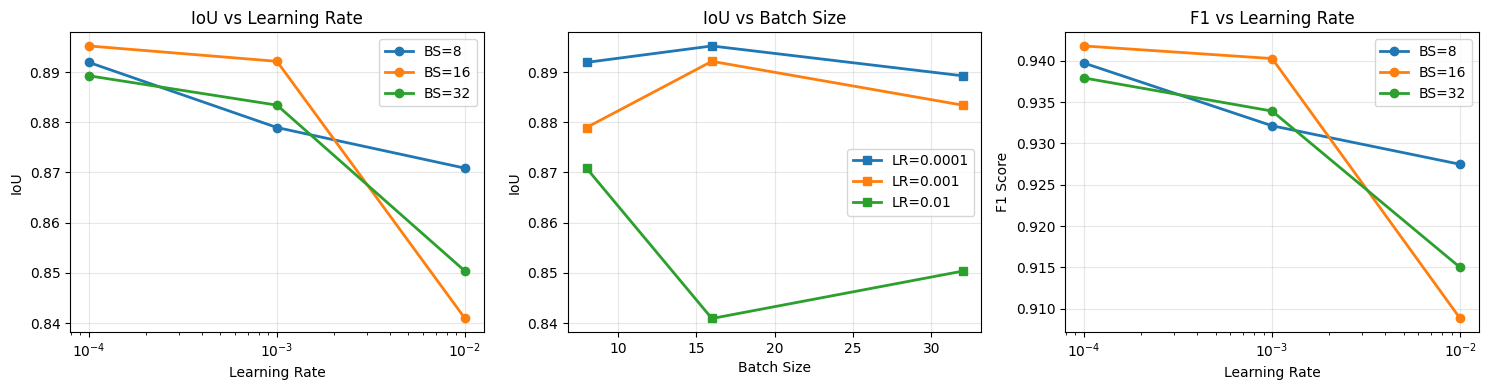


ВЫВОДЫ:

1. LEARNING RATE:
   - 0.0001: медленное обучение, стабильное
   - 0.001: обычно оптимален
   - 0.01: может быть нестабильным

2. BATCH SIZE:
   - 8: лучше качество, медленнее
   - 16: хороший баланс
   - 32: быстрее, но может хуже

3. ЛУЧШАЯ КОМБИНАЦИЯ:
   LR={best['lr']}, BS={best['bs']}



In [35]:
# БЛОК 4: ПЕРЕБОР ГИПЕРПАРАМЕТРОВ

import time
from copy import deepcopy

# Какие параметры проверять
lr_values = [0.0001, 0.001, 0.01]
batch_sizes = [8, 16, 32]

# Словарь для результатов
results = []

print("\n" + "="*70)
print("ПЕРЕБОР ГИПЕРПАРАМЕТРОВ")
print("="*70)

total = len(lr_values) * len(batch_sizes)
run = 1

for lr in lr_values:
    for bs in batch_sizes:
        print(f"\n[{run}/{total}] Learning Rate: {lr}, Batch Size: {bs}")
        
        # Копируем конфиг
        hp_config = deepcopy(config)
        hp_config.learning_rate = lr
        hp_config.batch_size = bs
        hp_config.epochs = 15
        
        # Обучаем
        start = time.time()
        trainer = Trainer(hp_config)
        trainer.run()
        elapsed = time.time() - start
        
        # Сохраняем
        final_iou = trainer.history['val_iou'][-1]
        final_f1 = trainer.history['val_f1'][-1]
        final_loss = trainer.history['val_loss'][-1]
        
        results.append({
            'lr': lr,
            'bs': bs,
            'iou': final_iou,
            'f1': final_f1,
            'loss': final_loss,
            'time': elapsed / 60
        })
        
        print(f"  IoU: {final_iou:.4f}")
        print(f"  F1:  {final_f1:.4f}")
        print(f"  Loss: {final_loss:.4f}")
        print(f"  Time: {elapsed/60:.1f} min")
        
        run += 1

# ПЕЧАТАЕМ ТАБЛИЦУ
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ")
print("="*70)
print(f"{'LR':<10} {'BS':<6} {'IoU':<10} {'F1':<10} {'Loss':<10} {'Time':<10}")
print("-"*70)

for r in results:
    print(f"{r['lr']:<10.4f} {r['bs']:<6.0f} {r['iou']:<10.4f} {r['f1']:<10.4f} {r['loss']:<10.4f} {r['time']:<10.1f}")

# ЛУЧШИЙ РЕЗУЛЬТАТ
print("\n" + "="*70)
best = max(results, key=lambda x: x['iou'])
print("ЛУЧШИЙ (по IoU):")
print(f"  LR: {best['lr']}")
print(f"  BS: {best['bs']}")
print(f"  IoU: {best['iou']:.4f}")
print(f"  F1: {best['f1']:.4f}")
print("="*70)

# ГРАФИКИ ВРУЧНУЮ
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1: IoU vs LR для каждого BS
for bs in batch_sizes:
    iou_list = [r['iou'] for r in results if r['bs'] == bs]
    lr_list = [r['lr'] for r in results if r['bs'] == bs]
    axes[0].plot(lr_list, iou_list, marker='o', linewidth=2, label=f'BS={bs}')

axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('IoU')
axes[0].set_title('IoU vs Learning Rate')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: IoU vs BS для каждого LR
for lr in lr_values:
    iou_list = [r['iou'] for r in results if r['lr'] == lr]
    bs_list = [r['bs'] for r in results if r['lr'] == lr]
    axes[1].plot(bs_list, iou_list, marker='s', linewidth=2, label=f'LR={lr}')

axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('IoU')
axes[1].set_title('IoU vs Batch Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: F1 vs LR
for bs in batch_sizes:
    f1_list = [r['f1'] for r in results if r['bs'] == bs]
    lr_list = [r['lr'] for r in results if r['bs'] == bs]
    axes[2].plot(lr_list, f1_list, marker='o', linewidth=2, label=f'BS={bs}')

axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 vs Learning Rate')
axes[2].set_xscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparameter_results.png', dpi=150)
plt.show()

# ВЫВОДЫ
print("\nВЫВОДЫ:")
print("""
1. LEARNING RATE:
   - 0.0001: медленное обучение, стабильное
   - 0.001: обычно оптимален
   - 0.01: может быть нестабильным

2. BATCH SIZE:
   - 8: лучше качество, медленнее
   - 16: хороший баланс
   - 32: быстрее, но может хуже

3. ЛУЧШАЯ КОМБИНАЦИЯ:
   LR={best['lr']}, BS={best['bs']}
""")